In [2]:
from pathlib import Path
import pandas as pd

data_dir = Path(r"C:\Users\hp\Downloads\ABO-BTI ABO Blood Typing")
image_dir = data_dir / "ABO-BTI_Images"
metadata_file = data_dir / "ABO-BTI_dataset.xlsx"

print("Dataset folder:", data_dir.exists())
print("Images folder:", image_dir.exists())
print("Metadata file:", metadata_file.exists())

image_files = [
    path for path in image_dir.rglob("*")
    if path.suffix.lower() in {".jpg", ".jpeg", ".png"}
]

print("\nTotal images:", len(image_files))
print("First 10 images:")
for path in image_files[:10]:
    print(path.relative_to(data_dir))

metadata = pd.read_excel(metadata_file)

print("\nMetadata shape:", metadata.shape)
print("Columns:", metadata.columns.tolist())
display(metadata.head())

Dataset folder: True
Images folder: True
Metadata file: False

Total images: 432
First 10 images:
ABO-BTI_Images\A negative\A_neg_10_1.jpg
ABO-BTI_Images\A negative\A_neg_10_2.jpg
ABO-BTI_Images\A negative\A_neg_10_3.jpg
ABO-BTI_Images\A negative\A_neg_11_1.jpg
ABO-BTI_Images\A negative\A_neg_11_2.jpg
ABO-BTI_Images\A negative\A_neg_11_3.jpg
ABO-BTI_Images\A negative\A_neg_12_1.jpg
ABO-BTI_Images\A negative\A_neg_12_2.jpg
ABO-BTI_Images\A negative\A_neg_12_3.jpg
ABO-BTI_Images\A negative\A_neg_13_1.jpg


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\hp\\Downloads\\ABO-BTI ABO Blood Typing\\ABO-BTI_dataset.xlsx'

In [4]:
print("Files in dataset folder:")

for path in sorted(data_dir.iterdir()):
    print(path.name, "| suffix:", path.suffix)

Files in dataset folder:
ABO-BTI _dataste.xlsx | suffix: .xlsx
ABO-BTI_Images | suffix: 
ABO-BTI_Images.zip | suffix: .zip
README.txt | suffix: .txt


In [5]:
metadata_candidates = list(data_dir.glob("*.xlsx"))

print("Excel files found:", metadata_candidates)

metadata_file = metadata_candidates[0]
metadata = pd.read_excel(metadata_file)

print("\nUsing:", metadata_file.name)
print("Metadata shape:", metadata.shape)
print("Columns:", metadata.columns.tolist())

display(metadata.head())

Excel files found: [WindowsPath('C:/Users/hp/Downloads/ABO-BTI ABO Blood Typing/ABO-BTI _dataste.xlsx')]


ImportError: `Import openpyxl` failed.  Use pip or conda to install the openpyxl package.

In [6]:
%pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpy

In [8]:
metadata_file = list(data_dir.glob("*.xlsx"))[0]
metadata = pd.read_excel(metadata_file)

print("Using:", metadata_file.name)
print("Metadata shape:", metadata.shape)
print("Columns:", metadata.columns.tolist())

display(metadata.head())

Using: ABO-BTI _dataste.xlsx
Metadata shape: (55, 11)
Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Source Data', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10']


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Source Data,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,Blood Type Distribution by Sex,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,Blood Type,Women (66%),Men (34%),Total Cases,NaN,Sex,Number of Cases,Percentage (%),NaN
4,NaN,NaN,A⁺,15,8,23,NaN,Women,108,0.66,NaN


In [10]:
excel = pd.ExcelFile(metadata_file)

print("Sheet names:", excel.sheet_names)

for sheet_name in excel.sheet_names:
    raw = pd.read_excel(metadata_file, sheet_name=sheet_name, header=None)
    non_empty = raw.dropna(how="all")

    print(f"\n--- {sheet_name} ---")
    print("Shape:", raw.shape)
    display(non_empty.head(15))

Sheet names: ['Source Data', 'Cleaned Data']

--- Source Data ---
Shape: (56, 11)


,0,1,2,3,4,5,6,7,8,9,10
0,NaN,NaN,NaN,Source Data,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,Blood Type Distribution by Sex,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,Blood Type,Women (66%),Men (34%),Total Cases,NaN,Sex,Number of Cases,Percentage (%),NaN
5,NaN,NaN,A⁺,15,8,23,NaN,Women,108,0.66,NaN
6,NaN,NaN,A⁻,13,7,20,NaN,Men,56,0.34,NaN
7,NaN,NaN,AB⁻,12,6,18,NaN,Total,164,1,NaN
8,NaN,NaN,AB⁺,13,6,19,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,B⁻,12,6,18,NaN,Blood Type,Total Cases,Total Image Numbers,NaN
10,NaN,NaN,B⁺,14,7,21,NaN,A⁺,23,69,NaN
11,NaN,NaN,O⁻,13,7,20,NaN,A⁻,20,60,NaN



--- Cleaned Data ---
Shape: (57, 11)


,0,1,2,3,4,5,6,7,8,9,10
0,NaN,NaN,NaN,Cleaned Data,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,Blood Type Distribution by Sex,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,Blood Type,Women (66%),Men (34%),Total Cases,NaN,Sex,Number of Cases,Percentage (%),NaN
6,NaN,NaN,A⁺,12,6,18,NaN,Women,95,0.66,NaN
7,NaN,NaN,A⁻,12,6,18,NaN,Men,49,0.34,NaN
8,NaN,NaN,AB⁻,11,7,18,NaN,Total,144,1,NaN
9,NaN,NaN,AB⁺,12,6,18,NaN,NaN,NaN,NaN,NaN
10,NaN,NaN,B⁻,12,6,18,NaN,Blood Type,Total Cases,Total Image Numbers,NaN
11,NaN,NaN,B⁺,12,6,18,NaN,A⁺,18,54,NaN
12,NaN,NaN,O⁻,12,6,18,NaN,A⁻,18,54,NaN


In [13]:
rows = []

for image_path in image_files:
    folder_label = image_path.parent.name
    filename = image_path.stem

    # Example: A_neg_10_1 -> A_neg_10
    case_id = re.sub(r"_\d+$", "", filename)

    rows.append({
        "image_path": str(image_path),
        "filename": image_path.name,
        "folder_label": folder_label,
        "blood_group": label_map[folder_label],
        "case_id": case_id,
    })

manifest = pd.DataFrame(rows)

print("Total images:", len(manifest))
print("Unique original cases:", manifest["case_id"].nunique())

print("\nImages per blood group:")
display(manifest["blood_group"].value_counts().sort_index())

print("\nOriginal cases per blood group:")
display(
    manifest.groupby("blood_group")["case_id"]
    .nunique()
    .sort_index()
    .rename("case_count")
)

display(manifest.head())

Total images: 432
Unique original cases: 144

Images per blood group:


blood_group
A+     54
A-     54
AB+    54
AB-    54
B+     54
B-     54
O+     54
O-     54
Name: count, dtype: int64


Original cases per blood group:


blood_group
A+     18
A-     18
AB+    18
AB-    18
B+     18
B-     18
O+     18
O-     18
Name: case_count, dtype: int64

,image_path,filename,folder_label,blood_group,case_id
0,C:\Users\hp\Downloads\ABO-BTI ABO Blood Typing...,A_neg_10_1.jpg,A negative,A-,A_neg_10
1,C:\Users\hp\Downloads\ABO-BTI ABO Blood Typing...,A_neg_10_2.jpg,A negative,A-,A_neg_10
2,C:\Users\hp\Downloads\ABO-BTI ABO Blood Typing...,A_neg_10_3.jpg,A negative,A-,A_neg_10
3,C:\Users\hp\Downloads\ABO-BTI ABO Blood Typing...,A_neg_11_1.jpg,A negative,A-,A_neg_11
4,C:\Users\hp\Downloads\ABO-BTI ABO Blood Typing...,A_neg_11_2.jpg,A negative,A-,A_neg_11


In [14]:
import numpy as np

rng = np.random.default_rng(42)

split_rows = []

for blood_group, group_data in manifest.groupby("blood_group", sort=True):
    cases = group_data["case_id"].drop_duplicates().to_numpy()
    shuffled_cases = rng.permutation(cases)

    train_cases = set(shuffled_cases[:12])
    val_cases = set(shuffled_cases[12:15])
    test_cases = set(shuffled_cases[15:18])

    for case_id in train_cases:
        split_rows.append((case_id, blood_group, "train"))

    for case_id in val_cases:
        split_rows.append((case_id, blood_group, "validation"))

    for case_id in test_cases:
        split_rows.append((case_id, blood_group, "test"))

case_splits = pd.DataFrame(
    split_rows,
    columns=["case_id", "blood_group", "split"]
)

dataset = manifest.merge(
    case_splits[["case_id", "split"]],
    on="case_id",
    how="left",
    validate="many_to_one",
)

print("Images by split:")
display(pd.crosstab(dataset["blood_group"], dataset["split"]))

print("\nOriginal cases by split:")
display(
    dataset.drop_duplicates("case_id")
    .pivot_table(
        index="blood_group",
        columns="split",
        values="case_id",
        aggfunc="count",
        fill_value=0,
    )
)

print("\nAny missing split?", dataset["split"].isna().any())
print("Any case in multiple splits?",
      dataset.groupby("case_id")["split"].nunique().gt(1).any())

Images by split:


split,test,train,validation
blood_group,,,
A+,9,36,9
A-,9,36,9
AB+,9,36,9
AB-,9,36,9
B+,9,36,9
B-,9,36,9
O+,9,36,9
O-,9,36,9



Original cases by split:


split,test,train,validation
blood_group,,,
A+,3,12,3
A-,3,12,3
AB+,3,12,3
AB-,3,12,3
B+,3,12,3
B-,3,12,3
O+,3,12,3
O-,3,12,3



Any missing split? False
Any case in multiple splits? False


Image dimensions:


,width,height,mode,format,image_count
0,1280,590,RGB,JPEG,432


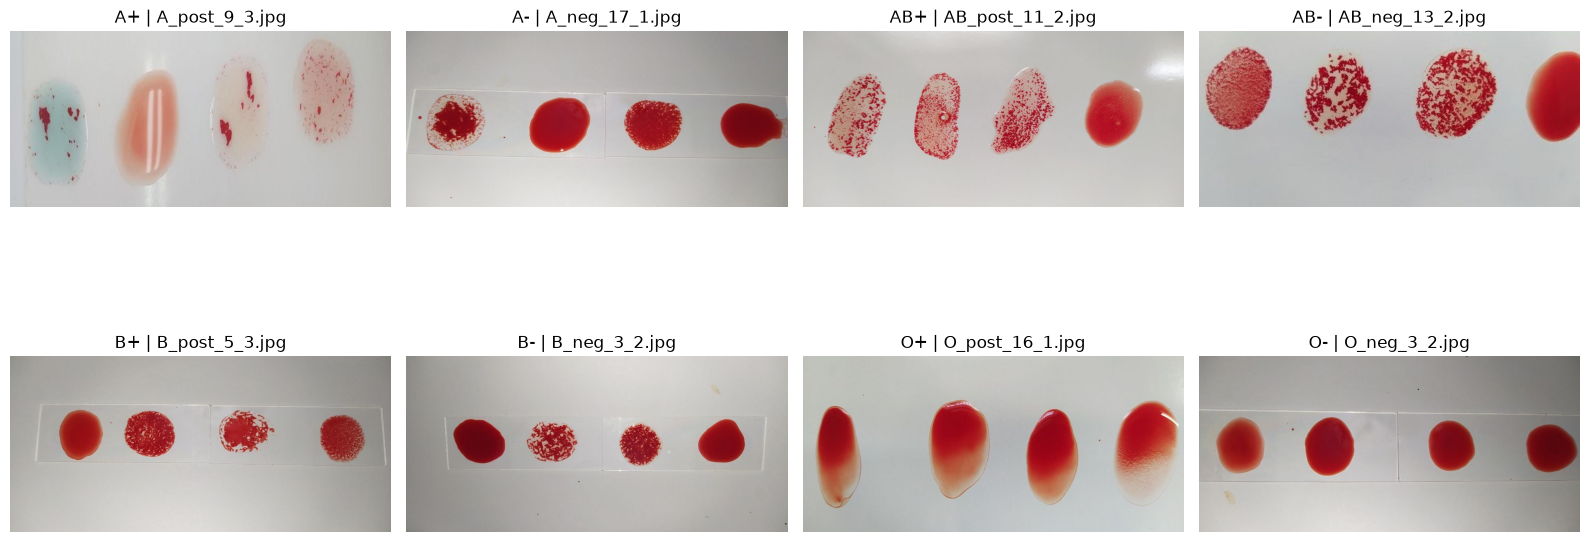

In [16]:
from PIL import Image
import matplotlib.pyplot as plt

image_info = []

for _, row in dataset.iterrows():
    with Image.open(row["image_path"]) as image:
        image_info.append({
            "filename": row["filename"],
            "blood_group": row["blood_group"],
            "split": row["split"],
            "width": image.width,
            "height": image.height,
            "mode": image.mode,
            "format": image.format,
        })

image_audit = pd.DataFrame(image_info)

print("Image dimensions:")
display(
    image_audit.groupby(["width", "height", "mode", "format"])
    .size()
    .rename("image_count")
    .reset_index()
)

samples = (
    dataset[dataset["split"] == "train"]
    .groupby("blood_group", group_keys=False)
    .sample(n=1, random_state=42)
    .sort_values("blood_group")
)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for axis, (_, row) in zip(axes.flat, samples.iterrows()):
    with Image.open(row["image_path"]) as image:
        axis.imshow(image)
    axis.set_title(f'{row["blood_group"]} | {row["filename"]}')
    axis.axis("off")

plt.tight_layout()
plt.show()

In [18]:
import numpy as np
from PIL import Image
from sklearn.preprocessing import LabelEncoder

IMAGE_SIZE = (128, 64)

def load_feature(image_path):
    with Image.open(image_path) as image:
        image = image.convert("L")
        image = image.resize(IMAGE_SIZE)
        pixels = np.asarray(image, dtype=np.float32) / 255.0
    return pixels.flatten()

X = np.vstack(dataset["image_path"].map(load_feature).to_numpy())

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(dataset["blood_group"])

split_masks = {
    split_name: dataset["split"].eq(split_name).to_numpy()
    for split_name in ["train", "validation", "test"]
}

X_train, y_train = X[split_masks["train"]], y[split_masks["train"]]
X_val, y_val = X[split_masks["validation"]], y[split_masks["validation"]]
X_test, y_test = X[split_masks["test"]], y[split_masks["test"]]

print("Classes:", label_encoder.classes_.tolist())
print("Feature shape:", X.shape)
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Classes: ['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']
Feature shape: (432, 8192)
Train: (288, 8192) (288,)
Validation: (72, 8192) (72,)
Test: (72, 8192) (72,)


In [20]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

baseline_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    class_weight="balanced",
)

baseline_model.fit(X_train, y_train)

val_predictions = baseline_model.predict(X_val)

val_accuracy = accuracy_score(y_val, val_predictions)

print(f"Validation accuracy: {val_accuracy:.4f}")

print("\nClassification report:")
print(
    classification_report(
        y_val,
        val_predictions,
        target_names=label_encoder.classes_,
        zero_division=0,
    )
)

confusion_df = pd.DataFrame(
    confusion_matrix(y_val, val_predictions),
    index=label_encoder.classes_,
    columns=label_encoder.classes_,
)

print("\nValidation confusion matrix:")
display(confusion_df)

Validation accuracy: 1.0000

Classification report:
              precision    recall  f1-score   support

          A+       1.00      1.00      1.00         9
          A-       1.00      1.00      1.00         9
         AB+       1.00      1.00      1.00         9
         AB-       1.00      1.00      1.00         9
          B+       1.00      1.00      1.00         9
          B-       1.00      1.00      1.00         9
          O+       1.00      1.00      1.00         9
          O-       1.00      1.00      1.00         9

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72


Validation confusion matrix:


,A+,A-,AB+,AB-,B+,B-,O+,O-
A+,9,0,0,0,0,0,0,0
A-,0,9,0,0,0,0,0,0
AB+,0,0,9,0,0,0,0,0
AB-,0,0,0,9,0,0,0,0
B+,0,0,0,0,9,0,0,0
B-,0,0,0,0,0,9,0,0
O+,0,0,0,0,0,0,9,0
O-,0,0,0,0,0,0,0,9


In [23]:
test_predictions = baseline_model.predict(X_test)

test_accuracy = accuracy_score(y_test, test_predictions)

print(f"Final held-out test accuracy: {test_accuracy:.4f}")

print("\nTest classification report:")
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=label_encoder.classes_,
        zero_division=0,
    )
)

test_confusion_df = pd.DataFrame(
    confusion_matrix(y_test, test_predictions),
    index=label_encoder.classes_,
    columns=label_encoder.classes_,
)

print("\nHeld-out test confusion matrix:")
display(test_confusion_df)

Final held-out test accuracy: 1.0000

Test classification report:
              precision    recall  f1-score   support

          A+       1.00      1.00      1.00         9
          A-       1.00      1.00      1.00         9
         AB+       1.00      1.00      1.00         9
         AB-       1.00      1.00      1.00         9
          B+       1.00      1.00      1.00         9
          B-       1.00      1.00      1.00         9
          O+       1.00      1.00      1.00         9
          O-       1.00      1.00      1.00         9

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72


Held-out test confusion matrix:


,A+,A-,AB+,AB-,B+,B-,O+,O-
A+,9,0,0,0,0,0,0,0
A-,0,9,0,0,0,0,0,0
AB+,0,0,9,0,0,0,0,0
AB-,0,0,0,9,0,0,0,0
B+,0,0,0,0,9,0,0,0
B-,0,0,0,0,0,9,0,0
O+,0,0,0,0,0,0,9,0
O-,0,0,0,0,0,0,0,9


In [25]:
import hashlib

def sha256_file(file_path):
    with open(file_path, "rb") as file:
        return hashlib.sha256(file.read()).hexdigest()

hash_audit = dataset.copy()
hash_audit["sha256"] = hash_audit["image_path"].map(sha256_file)

duplicate_hashes = (
    hash_audit.groupby("sha256")
    .filter(lambda group: group["split"].nunique() > 1)
    .sort_values("sha256")
)

print("Total unique file hashes:", hash_audit["sha256"].nunique())
print("Exact duplicate images across splits:", len(duplicate_hashes))

if duplicate_hashes.empty:
    print("\nPASS: No exact image file is shared across train, validation, and test.")
else:
    display(
        duplicate_hashes[
            ["filename", "blood_group", "case_id", "split", "sha256"]
        ].sort_values(["sha256", "split"])
    )

Total unique file hashes: 104
Exact duplicate images across splits: 298


,filename,blood_group,case_id,split,sha256
293,B_post_17_3.jpg,B+,B_post_17,test,006af2bc12b10b11b67547a69f806fd680628cb3c68ba9...
320,B_post_8_3.jpg,B+,B_post_8,train,006af2bc12b10b11b67547a69f806fd680628cb3c68ba9...
294,B_post_18_1.jpg,B+,B_post_18,train,006af2bc12b10b11b67547a69f806fd680628cb3c68ba9...
319,B_post_8_2.jpg,B+,B_post_8,train,006af2bc12b10b11b67547a69f806fd680628cb3c68ba9...
342,O_neg_16_1.jpg,O-,O_neg_16,train,009be5ceb626c1935a59f5b03048023dbd14ca18341d31...
...,...,...,...,...,...
110,AB_neg_10_3.jpg,AB-,AB_neg_10,train,efc735d0cd2c34b2058e48db3ce6c3cdd9304c3a56d71a...
142,AB_neg_3_2.jpg,AB-,AB_neg_3,train,efc735d0cd2c34b2058e48db3ce6c3cdd9304c3a56d71a...
124,AB_neg_15_2.jpg,AB-,AB_neg_15,validation,efc735d0cd2c34b2058e48db3ce6c3cdd9304c3a56d71a...
125,AB_neg_15_3.jpg,AB-,AB_neg_15,validation,efc735d0cd2c34b2058e48db3ce6c3cdd9304c3a56d71a...


In [27]:
hash_summary = (
    hash_audit.groupby("sha256")
    .agg(
        blood_groups=("blood_group", lambda values: sorted(set(values))),
        label_count=("blood_group", "nunique"),
        copies=("filename", "count"),
        case_count=("case_id", "nunique"),
        splits=("split", lambda values: sorted(set(values))),
    )
    .reset_index()
)

print("Unique images:", len(hash_summary))
print("Hashes with conflicting blood-group labels:",
      (hash_summary["label_count"] > 1).sum())

print("\nUnique images per blood group:")
display(
    hash_audit.drop_duplicates("sha256")
    ["blood_group"]
    .value_counts()
    .sort_index()
)

conflicting_labels = hash_summary.query("label_count > 1")

if conflicting_labels.empty:
    print("\nPASS: Duplicate images keep the same blood-group label.")
else:
    print("\nREJECT: Some exact same images have different labels.")
    display(conflicting_labels)

Unique images: 104
Hashes with conflicting blood-group labels: 0

Unique images per blood group:


blood_group
A+     21
A-      4
AB+     7
AB-     6
B+     17
B-      7
O+     31
O-     11
Name: count, dtype: int64


PASS: Duplicate images keep the same blood-group label.


## Dataset Decision: ABO-BTI Blood Typing Images

- The dataset initially contained 432 image rows across eight ABO/Rh classes.
- Group-safe splitting prevented the three named images of one case from being split across train, validation, and test sets.
- A file-hash audit found only 104 unique images and 298 duplicated rows across splits.
- The direct 8-class SVM validation and test accuracy of 100% is rejected because duplicated images created data leakage.
- Deduplication produced a severely imbalanced dataset: class counts ranged from 4 unique images for A− to 31 for O+.
- No duplicate image had conflicting blood-group labels, but the number and distribution of independent images are insufficient for reliable training or external generalization.
- This dataset may be used only for interface demonstration or qualitative image-review examples.
- No blood-group prediction model is saved, deployed, or connected to SmartCare from this dataset.

In [28]:
## Second Dataset Audit

In [30]:
from pathlib import Path
import pandas as pd

new_data_dir = Path(r"C:\Users\hp\Downloads\Original Dataset")

new_image_files = [
    path for path in new_data_dir.rglob("*")
    if path.suffix.lower() in {".jpg", ".jpeg", ".png"}
]

print("Dataset folder exists:", new_data_dir.exists())
print("Total image files:", len(new_image_files))

print("\nTop-level folders:")
for path in sorted(new_data_dir.iterdir()):
    print("-", path.name)

print("\nFirst 15 image paths:")
for path in new_image_files[:15]:
    print(path.relative_to(new_data_dir))

Dataset folder exists: True
Total image files: 565

Top-level folders:
- Original Dataset

First 15 image paths:
Original Dataset\A Negative\IMG_20260422_165131490.jpg
Original Dataset\A Negative\IMG_20260422_165133527.jpg
Original Dataset\A Negative\IMG_20260422_165139138.jpg
Original Dataset\A Negative\IMG_20260422_165143078.jpg
Original Dataset\A Negative\IMG_20260422_165147528.jpg
Original Dataset\A Negative\IMG_20260422_165150803.jpg
Original Dataset\A Negative\IMG_20260422_165153929.jpg
Original Dataset\A Negative\IMG_20260422_165200423.jpg
Original Dataset\A Negative\IMG_20260422_170521838.jpg
Original Dataset\A Negative\IMG_20260422_170524342.jpg
Original Dataset\A Negative\IMG_20260422_170530524.jpg
Original Dataset\A Negative\IMG_20260422_170533304.jpg
Original Dataset\A Negative\IMG_20260422_170537970.jpg
Original Dataset\A Negative\IMG_20260422_170543935.jpg
Original Dataset\A Negative\IMG_20260422_170549216.jpg


In [32]:
import hashlib
from collections import Counter

label_map_2 = {
    "A Positive": "A+",
    "A Negative": "A-",
    "B Positive": "B+",
    "B Negative": "B-",
    "AB Positive": "AB+",
    "AB Negative": "AB-",
    "O Positive": "O+",
    "O Negative": "O-",
}

rows_2 = []

for image_path in new_image_files:
    folder_label = image_path.parent.name

    rows_2.append({
        "image_path": str(image_path),
        "filename": image_path.name,
        "folder_label": folder_label,
        "blood_group": label_map_2[folder_label],
    })

manifest_2 = pd.DataFrame(rows_2)

def sha256_file(file_path):
    with open(file_path, "rb") as file:
        return hashlib.sha256(file.read()).hexdigest()

manifest_2["sha256"] = manifest_2["image_path"].map(sha256_file)

print("Images per class:")
display(manifest_2["blood_group"].value_counts().sort_index())

print("\nTotal images:", len(manifest_2))
print("Unique file hashes:", manifest_2["sha256"].nunique())
print("Exact duplicate rows:", len(manifest_2) - manifest_2["sha256"].nunique())

conflicting = (
    manifest_2.groupby("sha256")["blood_group"]
    .nunique()
    .gt(1)
    .sum()
)

print("Duplicate hashes with conflicting labels:", conflicting)

display(manifest_2.head())

Images per class:


blood_group
A+     122
A-      25
AB+     53
AB-     22
B+     148
B-       4
O+     163
O-      28
Name: count, dtype: int64


Total images: 565
Unique file hashes: 565
Exact duplicate rows: 0
Duplicate hashes with conflicting labels: 0


,image_path,filename,folder_label,blood_group,sha256
0,C:\Users\hp\Downloads\Original Dataset\Origina...,IMG_20260422_165131490.jpg,A Negative,A-,79d9783c7a95c704eec186f505ecbc2128112bad336826...
1,C:\Users\hp\Downloads\Original Dataset\Origina...,IMG_20260422_165133527.jpg,A Negative,A-,2a68cdac47c01603537c94ce00923b8638f09a1cd4e11c...
2,C:\Users\hp\Downloads\Original Dataset\Origina...,IMG_20260422_165139138.jpg,A Negative,A-,6767433d9e8d4bf1645e14064444ab80426fa84efd2b8a...
3,C:\Users\hp\Downloads\Original Dataset\Origina...,IMG_20260422_165143078.jpg,A Negative,A-,68093db83c098c18032f6528cb2a83648abd322f8949f1...
4,C:\Users\hp\Downloads\Original Dataset\Origina...,IMG_20260422_165147528.jpg,A Negative,A-,57437b12213838b64c53b23f5322894f18a1bfdb5cae9d...


## Dataset Decision: Blood Group Slide Image Dataset

- The dataset contains 565 image files across eight ABO/Rh classes.
- SHA-256 auditing found 565 unique files, with no exact duplicates and no conflicting labels.
- However, the class distribution is severely imbalanced, ranging from 4 images for B− to 163 images for O+.
- The dataset does not provide patient/sample identifiers, so near-duplicate or same-sample correlation cannot be ruled out.
- Training an eight-class blood-group classifier on this dataset would produce unreliable minority-class performance.
- This dataset is rejected for SmartCare blood-group model training.
- It may be retained only for interface demonstration and qualitative image-review examples.
- No model is trained, saved, deployed, or integrated from this dataset.

In [33]:

## BloodyWell Reaction-Level Dataset Audit

In [1]:
from pathlib import Path
import json

bloodywell_image_dir = Path(
    r"C:\Users\hp\Downloads\imgs\alvs_dataset_all"
)

bloodywell_metadata_dir = Path(
    r"C:\Users\hp\Downloads\BloodyWell"
)

experts_file = bloodywell_metadata_dir / "experts_info.json"
train_file = bloodywell_metadata_dir / "train_dataset_10_10_80.json"
test_file = bloodywell_metadata_dir / "test_dataset_10_10_80.json"

image_files_bw = [
    path for path in bloodywell_image_dir.rglob("*")
    if path.suffix.lower() in {".jpg", ".jpeg", ".png"}
]

print("Image folder exists:", bloodywell_image_dir.exists())
print("Total image files:", len(image_files_bw))

print("\nMetadata files:")
for file_path in [experts_file, train_file, test_file]:
    print(file_path.name, "->", file_path.exists())

with open(experts_file, "r", encoding="utf-8") as file:
    experts_info = json.load(file)

with open(train_file, "r", encoding="utf-8") as file:
    official_train = json.load(file)

with open(test_file, "r", encoding="utf-8") as file:
    official_test = json.load(file)

print("\nexperts_info type:", type(experts_info).__name__)
print("train split type:", type(official_train).__name__)
print("test split type:", type(official_test).__name__)

if isinstance(experts_info, dict):
    print("\nexperts_info top-level keys:", list(experts_info.keys())[:20])
elif isinstance(experts_info, list):
    print("\nexperts_info records:", len(experts_info))
    print("First record:", experts_info[0])

print("\nTrain split preview:", str(official_train)[:500])
print("\nTest split preview:", str(official_test)[:500])

Image folder exists: True
Total image files: 3906

Metadata files:
experts_info.json -> True
train_dataset_10_10_80.json -> True
test_dataset_10_10_80.json -> True

experts_info type: dict
train split type: dict
test split type: dict

experts_info top-level keys: ['01. CcEeCw_0_0.png', '01. CcEeCw_0_1.png', '01. CcEeCw_0_2.png', '01. CcEeCw_0_3.png', '01. CcEeCw_0_4.png', '01. CcEeCw_1_0.png', '01. CcEeCw_1_1.png', '01. CcEeCw_1_2.png', '01. CcEeCw_1_3.png', '01. CcEeCw_1_4.png', '01. CcEeCw_2_0.png', '01. CcEeCw_2_1.png', '01. CcEeCw_2_2.png', '01. CcEeCw_2_3.png', '01. CcEeCw_2_4.png', '01. CcEeCw_3_0.png', '01. CcEeCw_3_1.png', '01. CcEeCw_3_2.png', '01. CcEeCw_3_3.png', '01. CcEeCw_3_4.png']

Train split preview: {'01. CcEeCw_0_0.png': {'row_idx': 0, 'col_idx': 0, 'split_type': 'train', 'reagent': 'C', 'cx': 1208, 'cy': 876, 'r': 287, 'is_empty': False, 'gt_result': 1, 'invalid': False}, '01. CcEeCw_0_1.png': {'row_idx': 0, 'col_idx': 1, 'split_type': 'train', 'reagent': 'c', 'cx':

In [2]:
import pandas as pd

def split_dict_to_df(split_data, source_name):
    rows = []
    for filename, info in split_data.items():
        rows.append({
            "filename": filename,
            "source_file": source_name,
            "official_split": info.get("split_type"),
            "reagent": info.get("reagent"),
            "gt_result": info.get("gt_result"),
            "is_empty": info.get("is_empty"),
            "invalid": info.get("invalid"),
            "row_idx": info.get("row_idx"),
            "col_idx": info.get("col_idx"),
        })
    return pd.DataFrame(rows)

train_df_bw = split_dict_to_df(official_train, "train_dataset_10_10_80.json")
test_df_bw = split_dict_to_df(official_test, "test_dataset_10_10_80.json")

bw_data = pd.concat([train_df_bw, test_df_bw], ignore_index=True)

image_path_by_name = {path.name: str(path) for path in image_files_bw}
bw_data["image_path"] = bw_data["filename"].map(image_path_by_name)

print("Metadata rows:", len(bw_data))
print("Unique metadata filenames:", bw_data["filename"].nunique())
print("Matching local image files:", bw_data["image_path"].notna().sum())
print("Missing local image files:", bw_data["image_path"].isna().sum())

print("\nOfficial split counts:")
display(bw_data["official_split"].value_counts(dropna=False))

print("\nGround-truth reaction labels:")
display(bw_data["gt_result"].value_counts(dropna=False).sort_index())

print("\nEmpty / invalid wells:")
display(
    bw_data.groupby(["is_empty", "invalid"]).size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("\nReagent distribution:")
display(
    bw_data["reagent"].value_counts()
    .rename_axis("reagent")
    .reset_index(name="count")
)

print("\nReaction-label balance by split:")
display(
    pd.crosstab(
        bw_data["official_split"],
        bw_data["gt_result"],
        margins=True
    )
)

display(bw_data.head())

Metadata rows: 3139
Unique metadata filenames: 3139
Matching local image files: 3139
Missing local image files: 0

Official split counts:


official_split
test     2516
train     623
Name: count, dtype: int64


Ground-truth reaction labels:


gt_result
0    1553
1    1586
Name: count, dtype: int64


Empty / invalid wells:


...


Reagent distribution:


,reagent,count
0,D,288
1,A,282
2,B,282
3,K,274
4,O(I),252
5,C,234
6,c,234
7,E,234
8,e,234
9,A(II),228



Reaction-label balance by split:


gt_result,0,1,All
official_split,,,
test,1245,1271,2516
train,308,315,623
All,1553,1586,3139


,filename,source_file,official_split,reagent,gt_result,is_empty,invalid,row_idx,col_idx,image_path
0,01. CcEeCw_0_0.png,train_dataset_10_10_80.json,train,C,1,False,False,0,0,C:\Users\hp\Downloads\imgs\alvs_dataset_all\01...
1,01. CcEeCw_0_1.png,train_dataset_10_10_80.json,train,c,1,False,False,0,1,C:\Users\hp\Downloads\imgs\alvs_dataset_all\01...
2,01. CcEeCw_0_2.png,train_dataset_10_10_80.json,train,E,1,False,False,0,2,C:\Users\hp\Downloads\imgs\alvs_dataset_all\01...
3,01. CcEeCw_0_3.png,train_dataset_10_10_80.json,train,e,1,False,False,0,3,C:\Users\hp\Downloads\imgs\alvs_dataset_all\01...
4,01. CcEeCw_0_4.png,train_dataset_10_10_80.json,train,Cw,0,False,False,0,4,C:\Users\hp\Downloads\imgs\alvs_dataset_all\01...


In [3]:
import hashlib
import re
from pathlib import Path

def sha256_file(file_path):
    file_hash = hashlib.sha256()
    with open(file_path, "rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            file_hash.update(block)
    return file_hash.hexdigest()

def get_sheet_id(filename):
    # Example:
    # "01. CcEeCw_0_0.png" -> "01. CcEeCw"
    return re.sub(r"_\d+_\d+\.png$", "", filename)

audit_bw = bw_data.copy()
audit_bw["sheet_id"] = audit_bw["filename"].apply(get_sheet_id)

print("Unique source sheets:", audit_bw["sheet_id"].nunique())

print("\nSame source sheet in both official splits:")
split_per_sheet = audit_bw.groupby("sheet_id")["official_split"].nunique()
leaked_sheets = split_per_sheet[split_per_sheet > 1]

print("Count:", len(leaked_sheets))
if len(leaked_sheets) > 0:
    display(
        audit_bw[audit_bw["sheet_id"].isin(leaked_sheets.index)]
        .sort_values(["sheet_id", "official_split", "filename"])
        [["filename", "sheet_id", "official_split", "reagent", "gt_result"]]
        .head(30)
    )
else:
    print("PASS: No source sheet appears in both train and test.")

print("\nCalculating SHA-256 hashes. This can take a little time...")
audit_bw["sha256"] = audit_bw["image_path"].apply(sha256_file)

hash_split_counts = audit_bw.groupby("sha256")["official_split"].nunique()
cross_split_hashes = hash_split_counts[hash_split_counts > 1]

print("\nTotal metadata images:", len(audit_bw))
print("Unique image hashes:", audit_bw["sha256"].nunique())
print("Exact duplicate rows:", len(audit_bw) - audit_bw["sha256"].nunique())
print("Exact image hashes crossing train/test:", len(cross_split_hashes))

if len(cross_split_hashes) > 0:
    display(
        audit_bw[audit_bw["sha256"].isin(cross_split_hashes.index)]
        .sort_values(["sha256", "official_split"])
        [["filename", "sheet_id", "official_split", "reagent", "gt_result", "sha256"]]
        .head(30)
    )
else:
    print("PASS: No exact duplicate image crosses train and test.")

Unique source sheets: 92

Same source sheet in both official splits:
Count: 18


,filename,sheet_id,official_split,reagent,gt_result
623,05. CcEeCwKk_3_1.png,05. CcEeCwKk,test,c,0
624,05. CcEeCwKk_5_1.png,05. CcEeCwKk,test,c,0
300,05. CcEeCwKk_0_0.png,05. CcEeCwKk,train,C,1
301,05. CcEeCwKk_0_1.png,05. CcEeCwKk,train,c,1
302,05. CcEeCwKk_0_2.png,05. CcEeCwKk,train,E,0
303,05. CcEeCwKk_0_3.png,05. CcEeCwKk,train,e,1
304,05. CcEeCwKk_0_4.png,05. CcEeCwKk,train,Cw,0
305,05. CcEeCwKk_0_5.png,05. CcEeCwKk,train,K,0
306,05. CcEeCwKk_0_6.png,05. CcEeCwKk,train,k,1
307,05. CcEeCwKk_1_0.png,05. CcEeCwKk,train,C,1



Calculating SHA-256 hashes. This can take a little time...

Total metadata images: 3139
Unique image hashes: 3139
Exact duplicate rows: 0
Exact image hashes crossing train/test: 0
PASS: No exact duplicate image crosses train and test.


In [4]:
from sklearn.model_selection import StratifiedGroupKFold

model_data = audit_bw.copy().reset_index(drop=True)

# Step 1: 80% train+validation, 20% final held-out test
outer_splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_val_idx, test_idx = next(
    outer_splitter.split(
        model_data,
        y=model_data["gt_result"],
        groups=model_data["sheet_id"]
    )
)

train_val_data = model_data.iloc[train_val_idx].copy()
test_data = model_data.iloc[test_idx].copy()

# Step 2: from the 80%, keep 20% for validation
# Final approximate ratio: train 64%, validation 16%, test 20%
inner_splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx_local, validation_idx_local = next(
    inner_splitter.split(
        train_val_data,
        y=train_val_data["gt_result"],
        groups=train_val_data["sheet_id"]
    )
)

train_data = train_val_data.iloc[train_idx_local].copy()
validation_data = train_val_data.iloc[validation_idx_local].copy()

train_data["clean_split"] = "train"
validation_data["clean_split"] = "validation"
test_data["clean_split"] = "test"

clean_split_data = pd.concat(
    [train_data, validation_data, test_data],
    ignore_index=True
)

print("Images by clean split:")
display(
    clean_split_data["clean_split"]
    .value_counts()
    .reindex(["train", "validation", "test"])
)

print("\nReaction-label balance by clean split:")
display(
    pd.crosstab(
        clean_split_data["clean_split"],
        clean_split_data["gt_result"],
        margins=True
    ).reindex(["train", "validation", "test", "All"])
)

print("\nUnique source sheets by clean split:")
display(
    clean_split_data.groupby("clean_split")["sheet_id"]
    .nunique()
    .reindex(["train", "validation", "test"])
)

sheet_split_check = clean_split_data.groupby("sheet_id")["clean_split"].nunique()
print("\nAny sheet in multiple clean splits?", (sheet_split_check > 1).any())

hash_split_check = clean_split_data.groupby("sha256")["clean_split"].nunique()
print("Any exact duplicate image in multiple clean splits?", (hash_split_check > 1).any())

Images by clean split:


clean_split
train         2010
validation     504
test           625
Name: count, dtype: int64


Reaction-label balance by clean split:


gt_result,0,1,All
clean_split,,,
train,1005,1005,2010
validation,244,260,504
test,304,321,625
All,1553,1586,3139



Unique source sheets by clean split:


clean_split
train         59
validation    15
test          18
Name: sheet_id, dtype: int64


Any sheet in multiple clean splits? False
Any exact duplicate image in multiple clean splits? False


Image dimensions and formats:


,width,height,mode,format,image_count
0,574,574,RGB,PNG,1536
1,598,598,RGB,PNG,715
2,542,542,RGB,PNG,370
3,576,576,RGB,PNG,318
4,572,572,RGB,PNG,42
5,578,578,RGB,PNG,25
6,570,570,RGB,PNG,23
7,565,565,RGB,PNG,19
8,592,592,RGB,PNG,14
9,596,596,RGB,PNG,13


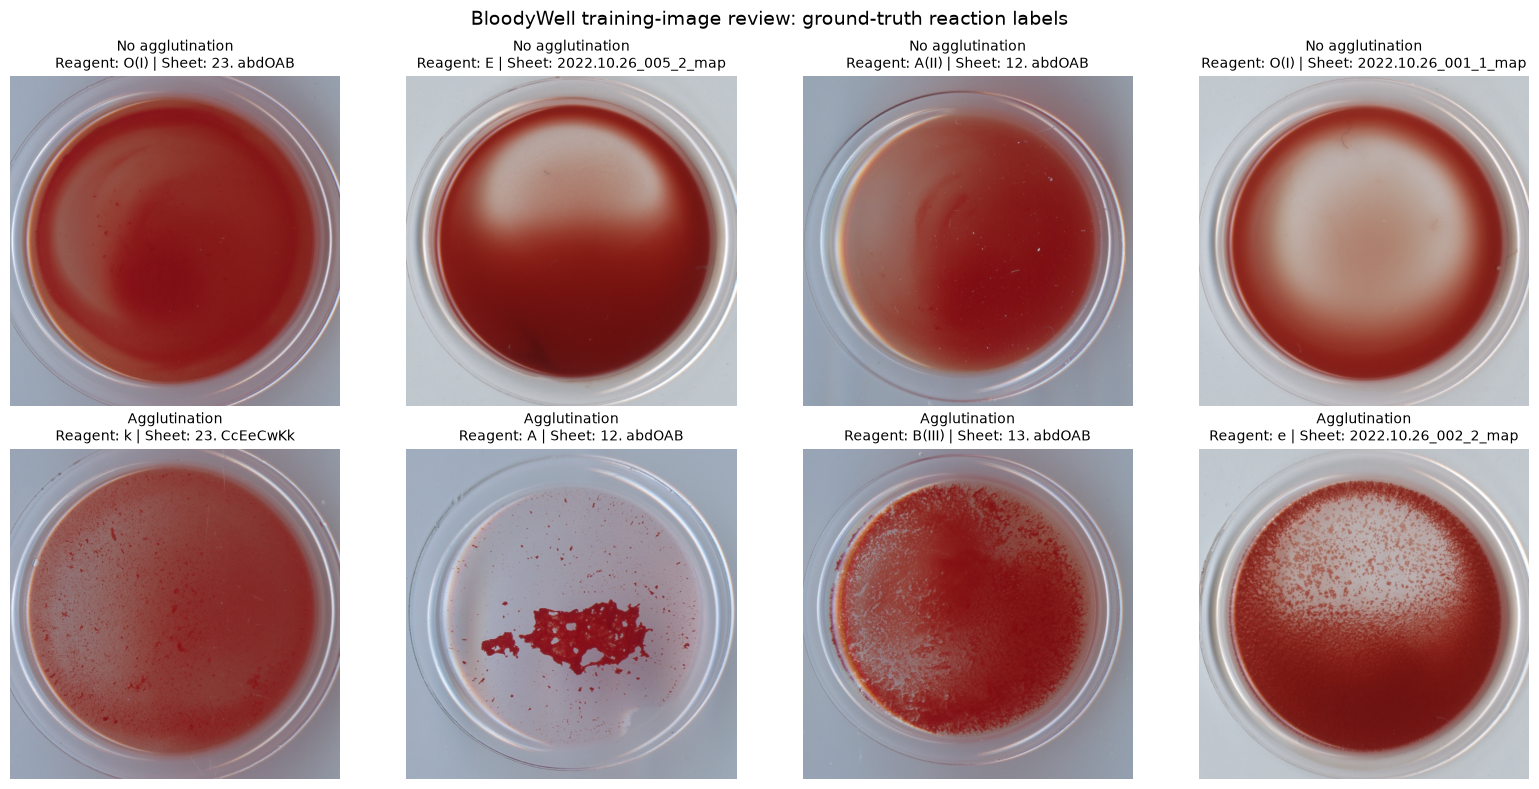

In [5]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def get_image_info(image_path):
    with Image.open(image_path) as image:
        return {
            "width": image.width,
            "height": image.height,
            "mode": image.mode,
            "format": image.format,
        }

image_info = pd.DataFrame(
    [get_image_info(path) for path in clean_split_data["image_path"]]
)

print("Image dimensions and formats:")
display(
    image_info.value_counts()
    .rename("image_count")
    .reset_index()
    .sort_values("image_count", ascending=False)
)

# Show balanced examples from training data only
sample_negative = train_data[train_data["gt_result"] == 0].sample(
    n=4, random_state=42
)
sample_positive = train_data[train_data["gt_result"] == 1].sample(
    n=4, random_state=42
)

preview_data = pd.concat([sample_negative, sample_positive])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for axis, (_, row) in zip(axes.flat, preview_data.iterrows()):
    image = Image.open(row["image_path"]).convert("RGB")
    axis.imshow(image)
    reaction_name = (
        "No agglutination"
        if row["gt_result"] == 0
        else "Agglutination"
    )
    axis.set_title(
        f"{reaction_name}\n"
        f"Reagent: {row['reagent']} | Sheet: {row['sheet_id']}",
        fontsize=10
    )
    axis.axis("off")

plt.suptitle(
    "BloodyWell training-image review: ground-truth reaction labels",
    fontsize=14,
    y=0.98
)
plt.tight_layout()
plt.show()

In [6]:
try:
    from skimage.feature import hog
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
    print("PASS: Required packages are available.")
except ModuleNotFoundError as error:
    print("Missing package:", error.name)
    print("Run this in a new cell, then restart this cell:")
    print("%pip install scikit-image")

PASS: Required packages are available.


In [47]:
%pip install scikit-image

Note: you may need to restart the kernel to use updated packages.


In [8]:
import numpy as np
from PIL import Image
from skimage.feature import hog

IMAGE_SIZE = (128, 128)

def extract_hog_features(image_path):
    with Image.open(image_path) as image:
        image = image.convert("L")
        image = image.resize(IMAGE_SIZE, Image.Resampling.LANCZOS)
        image_array = np.asarray(image, dtype=np.float32) / 255.0

    return hog(
        image_array,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

def make_feature_matrix(dataframe, split_name):
    features = []
    total = len(dataframe)

    for position, image_path in enumerate(dataframe["image_path"], start=1):
        features.append(extract_hog_features(image_path))

        if position % 250 == 0 or position == total:
            print(f"{split_name}: {position}/{total} images processed")

    return np.vstack(features)

X_train = make_feature_matrix(train_data, "Train")
X_validation = make_feature_matrix(validation_data, "Validation")
X_test = make_feature_matrix(test_data, "Test")

y_train = train_data["gt_result"].to_numpy()
y_validation = validation_data["gt_result"].to_numpy()
y_test = test_data["gt_result"].to_numpy()

print("\nFeature matrices:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_validation:", X_validation.shape, "| y_validation:", y_validation.shape)
print("X_test:", X_test.shape, "| y_test:", y_test.shape)
print("Features per image:", X_train.shape[1])

Train: 250/2010 images processed
Train: 500/2010 images processed
Train: 750/2010 images processed
Train: 1000/2010 images processed
Train: 1250/2010 images processed
Train: 1500/2010 images processed
Train: 1750/2010 images processed
Train: 2000/2010 images processed
Train: 2010/2010 images processed
Validation: 250/504 images processed
Validation: 500/504 images processed
Validation: 504/504 images processed
Test: 250/625 images processed
Test: 500/625 images processed
Test: 625/625 images processed

Feature matrices:
X_train: (2010, 1764) | y_train: (2010,)
X_validation: (504, 1764) | y_validation: (504,)
X_test: (625, 1764) | y_test: (625,)
Features per image: 1764


Validation accuracy: 0.9444

Validation classification report:
                  precision    recall  f1-score   support

No agglutination     0.9091    0.9836    0.9449       244
   Agglutination     0.9833    0.9077    0.9440       260

        accuracy                         0.9444       504
       macro avg     0.9462    0.9456    0.9444       504
    weighted avg     0.9474    0.9444    0.9444       504



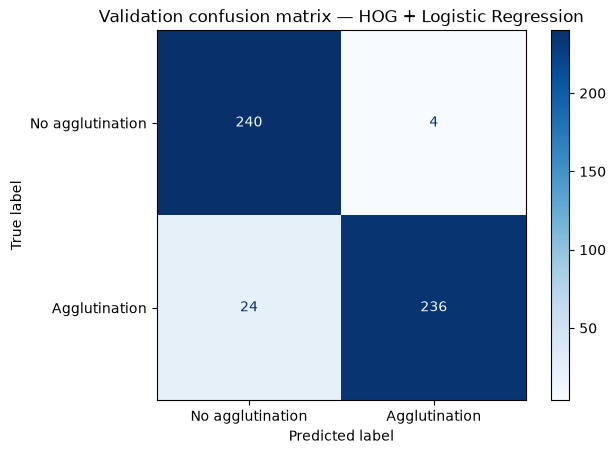

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        C=1.0,
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)

validation_predictions = baseline_model.predict(X_validation)
validation_probabilities = baseline_model.predict_proba(X_validation)[:, 1]

print("Validation accuracy:", round(
    accuracy_score(y_validation, validation_predictions), 4
))

print("\nValidation classification report:")
print(
    classification_report(
        y_validation,
        validation_predictions,
        target_names=["No agglutination", "Agglutination"],
        digits=4
    )
)

validation_cm = confusion_matrix(y_validation, validation_predictions)

ConfusionMatrixDisplay(
    confusion_matrix=validation_cm,
    display_labels=["No agglutination", "Agglutination"]
).plot(cmap="Blues", values_format="d")

plt.title("Validation confusion matrix — HOG + Logistic Regression")
plt.show()

Brier score (lower is better probability quality): 0.0515


,confidence_threshold,accepted_cases,manual_review_cases,coverage_percent,accepted_accuracy_percent,wrong_accepted_cases
0,0.50,504,0,100.00,94.44,28
1,0.55,504,0,100.00,94.44,28
2,0.60,502,2,99.60,94.62,27
3,0.65,502,2,99.60,94.62,27
4,0.70,501,3,99.40,94.81,26
5,0.75,497,7,98.61,94.97,25
6,0.80,496,8,98.41,94.96,25
7,0.85,494,10,98.02,95.14,24
8,0.90,487,17,96.63,95.28,23


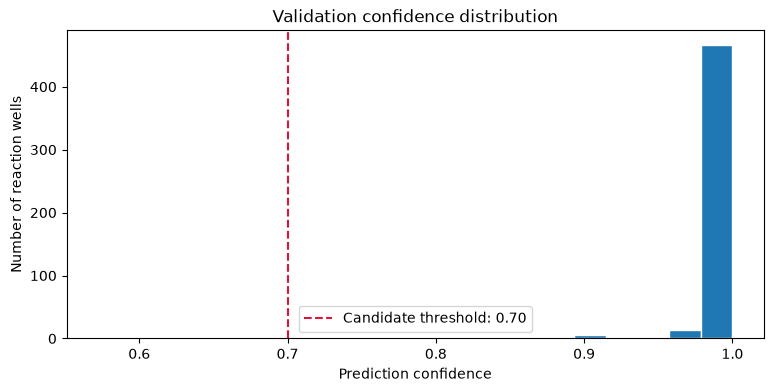

In [12]:
from sklearn.metrics import brier_score_loss

validation_confidence = np.maximum(
    validation_probabilities,
    1 - validation_probabilities
)

threshold_rows = []

for threshold in [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]:
    accepted = validation_confidence >= threshold

    accepted_count = accepted.sum()
    uncertain_count = (~accepted).sum()
    coverage = accepted.mean()

    if accepted_count > 0:
        accepted_accuracy = accuracy_score(
            y_validation[accepted],
            validation_predictions[accepted]
        )
        accepted_errors = (
            y_validation[accepted] != validation_predictions[accepted]
        ).sum()
    else:
        accepted_accuracy = np.nan
        accepted_errors = np.nan

    threshold_rows.append({
        "confidence_threshold": threshold,
        "accepted_cases": accepted_count,
        "manual_review_cases": uncertain_count,
        "coverage_percent": round(coverage * 100, 2),
        "accepted_accuracy_percent": round(accepted_accuracy * 100, 2),
        "wrong_accepted_cases": accepted_errors,
    })

threshold_results = pd.DataFrame(threshold_rows)

print(
    "Brier score (lower is better probability quality):",
    round(brier_score_loss(y_validation, validation_probabilities), 4)
)

display(threshold_results)

# Confidence distribution
plt.figure(figsize=(9, 4))
plt.hist(validation_confidence, bins=20, edgecolor="white", color="#1f77b4")
plt.axvline(0.70, color="crimson", linestyle="--", label="Candidate threshold: 0.70")
plt.title("Validation confidence distribution")
plt.xlabel("Prediction confidence")
plt.ylabel("Number of reaction wells")
plt.legend()
plt.show()

Final held-out test results
-----------------------------
Raw test accuracy: 95.04 %
Brier score: 0.0428
Review threshold: 0.9
Manual-review wells: 26 / 625
Accepted coverage: 95.84 %
Accepted-case accuracy: 96.33 %
Wrong accepted wells: 22

Full held-out test classification report:
                  precision    recall  f1-score   support

No agglutination     0.9417    0.9572    0.9494       304
   Agglutination     0.9589    0.9439    0.9513       321

        accuracy                         0.9504       625
       macro avg     0.9503    0.9506    0.9504       625
    weighted avg     0.9505    0.9504    0.9504       625



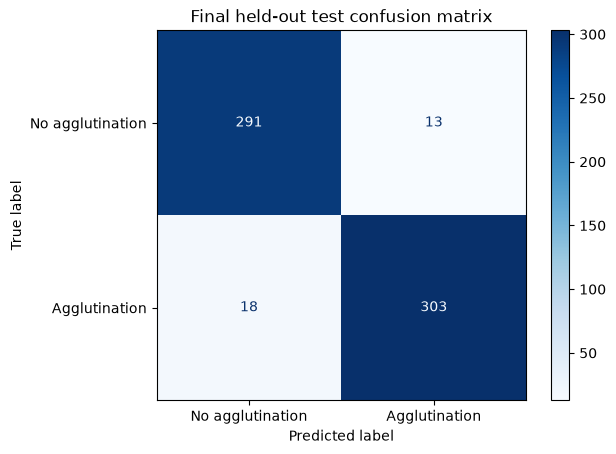

,filename,reagent,gt_result,predicted_result,agglutination_probability,confidence,decision_status
264,04. abdOAB_0_0.png,A,1,1,9.999949e-01,0.999995,AI-assisted result — clinician verification re...
265,04. abdOAB_0_1.png,B,0,0,3.815334e-06,0.999996,AI-assisted result — clinician verification re...
266,04. abdOAB_0_2.png,D,1,1,9.999999e-01,1.000000,AI-assisted result — clinician verification re...
267,04. abdOAB_0_3.png,O(I),0,0,2.520727e-06,0.999997,AI-assisted result — clinician verification re...
268,04. abdOAB_0_4.png,A(II),0,0,3.546522e-03,0.996453,AI-assisted result — clinician verification re...
269,04. abdOAB_0_5.png,B(III),1,1,9.999999e-01,1.000000,AI-assisted result — clinician verification re...
270,04. abdOAB_1_0.png,A,0,0,1.738498e-09,1.000000,AI-assisted result — clinician verification re...
271,04. abdOAB_1_1.png,B,0,0,2.037721e-07,1.000000,AI-assisted result — clinician verification re...
272,04. abdOAB_1_2.png,D,1,1,1.000000e+00,1.000000,AI-assisted result — clinician verification re...
273,04. abdOAB_1_3.png,O(I),0,0,2.694088e-03,0.997306,AI-assisted result — clinician verification re...


In [14]:
REVIEW_THRESHOLD = 0.90

test_predictions = baseline_model.predict(X_test)
test_probabilities = baseline_model.predict_proba(X_test)[:, 1]
test_confidence = np.maximum(test_probabilities, 1 - test_probabilities)

test_requires_review = test_confidence < REVIEW_THRESHOLD
test_accepted = ~test_requires_review

test_status = np.where(
    test_requires_review,
    "Manual review required",
    "AI-assisted result — clinician verification required"
)

raw_test_accuracy = accuracy_score(y_test, test_predictions)

accepted_test_accuracy = accuracy_score(
    y_test[test_accepted],
    test_predictions[test_accepted]
)

print("Final held-out test results")
print("-----------------------------")
print("Raw test accuracy:", round(raw_test_accuracy * 100, 2), "%")
print("Brier score:", round(brier_score_loss(y_test, test_probabilities), 4))
print("Review threshold:", REVIEW_THRESHOLD)
print("Manual-review wells:", test_requires_review.sum(), "/", len(y_test))
print("Accepted coverage:", round(test_accepted.mean() * 100, 2), "%")
print("Accepted-case accuracy:", round(accepted_test_accuracy * 100, 2), "%")
print(
    "Wrong accepted wells:",
    (y_test[test_accepted] != test_predictions[test_accepted]).sum()
)

print("\nFull held-out test classification report:")
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=["No agglutination", "Agglutination"],
        digits=4
    )
)

test_cm = confusion_matrix(y_test, test_predictions)

ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=["No agglutination", "Agglutination"]
).plot(cmap="Blues", values_format="d")

plt.title("Final held-out test confusion matrix")
plt.show()

test_results = test_data[
    ["filename", "sheet_id", "reagent", "gt_result", "image_path"]
].copy()

test_results["predicted_result"] = test_predictions
test_results["agglutination_probability"] = test_probabilities
test_results["confidence"] = test_confidence
test_results["decision_status"] = test_status

display(
    test_results[
        [
            "filename",
            "reagent",
            "gt_result",
            "predicted_result",
            "agglutination_probability",
            "confidence",
            "decision_status",
        ]
    ].head(10)
)

In [16]:
from pathlib import Path
import json
import joblib

artifact_dir = Path(
    r"C:\Users\hp\Documents\ChatGPT\MediFlow AI — Intelligent Hospital Navigation, Queue Management & Patient Care Platform\ml-artifacts"
)
artifact_dir.mkdir(parents=True, exist_ok=True)

feature_config = {
    "model_name": "HOG + Logistic Regression",
    "task": "Binary agglutination detection",
    "image_mode": "grayscale",
    "image_size": [128, 128],
    "hog_orientations": 9,
    "pixels_per_cell": [16, 16],
    "cells_per_block": [2, 2],
    "review_threshold": 0.90,
    "positive_label": 1,
    "negative_label": 0,
    "positive_label_name": "Agglutination detected",
    "negative_label_name": "No agglutination detected",
    "clinical_note": (
        "AI-assisted prototype only. "
        "Every result requires qualified laboratory professional verification."
    ),
}

evaluation_summary = {
    "dataset": "BloodyWell",
    "total_labelled_wells": 3139,
    "split_method": "Sheet-safe StratifiedGroupKFold",
    "train_wells": int(len(train_data)),
    "validation_wells": int(len(validation_data)),
    "held_out_test_wells": int(len(test_data)),
    "validation_accuracy": float(
        accuracy_score(y_validation, validation_predictions)
    ),
    "test_accuracy": float(raw_test_accuracy),
    "test_brier_score": float(
        brier_score_loss(y_test, test_probabilities)
    ),
    "review_threshold": REVIEW_THRESHOLD,
    "test_manual_review_wells": int(test_requires_review.sum()),
    "test_accepted_coverage": float(test_accepted.mean()),
    "test_accepted_accuracy": float(accepted_test_accuracy),
    "test_wrong_accepted_wells": int(
        (y_test[test_accepted] != test_predictions[test_accepted]).sum()
    ),
    "warning": (
        "Not a clinical diagnostic device. "
        "Do not use without qualified laboratory verification."
    ),
}

joblib.dump(baseline_model, artifact_dir / "agglutination_hog_logreg.joblib")

with open(artifact_dir / "feature_config.json", "w", encoding="utf-8") as file:
    json.dump(feature_config, file, indent=2)

with open(artifact_dir / "evaluation_summary.json", "w", encoding="utf-8") as file:
    json.dump(evaluation_summary, file, indent=2)

test_results.to_csv(
    artifact_dir / "held_out_test_predictions.csv",
    index=False
)

print("Saved artifacts:")
for path in artifact_dir.iterdir():
    print("-", path.name)

Saved artifacts:
- agglutination_hog_logreg.joblib
- evaluation_summary.json
- feature_config.json
- held_out_test_predictions.csv


In [18]:
from itertools import product
import pandas as pd

REVIEW_THRESHOLD = 0.90

def reaction_assessment(agglutination_probability):
    predicted_positive = agglutination_probability >= 0.50
    confidence = max(
        agglutination_probability,
        1 - agglutination_probability
    )

    return {
        "agglutination_detected": predicted_positive,
        "agglutination_probability": round(
            float(agglutination_probability) * 100, 2
        ),
        "confidence": round(float(confidence) * 100, 2),
        "requires_manual_review": confidence < REVIEW_THRESHOLD,
    }

def interpret_blood_group(anti_a_probability, anti_b_probability, anti_d_probability):
    reactions = {
        "Anti-A": reaction_assessment(anti_a_probability),
        "Anti-B": reaction_assessment(anti_b_probability),
        "Anti-D": reaction_assessment(anti_d_probability),
    }

    uncertain_reactions = [
        reagent for reagent, result in reactions.items()
        if result["requires_manual_review"]
    ]

    if uncertain_reactions:
        return {
            "blood_group": None,
            "verification_status": "Manual verification required before interpretation",
            "reason": (
                "Low-confidence reaction(s): "
                + ", ".join(uncertain_reactions)
                + ". No blood-group conclusion is generated."
            ),
            "reactions": reactions,
        }

    anti_a = reactions["Anti-A"]["agglutination_detected"]
    anti_b = reactions["Anti-B"]["agglutination_detected"]
    anti_d = reactions["Anti-D"]["agglutination_detected"]

    blood_group_map = {
        (False, False, False): "O-",
        (False, False, True): "O+",
        (True, False, False): "A-",
        (True, False, True): "A+",
        (False, True, False): "B-",
        (False, True, True): "B+",
        (True, True, False): "AB-",
        (True, True, True): "AB+",
    }

    blood_group = blood_group_map[(anti_a, anti_b, anti_d)]

    positive_reagents = [
        reagent for reagent, result in reactions.items()
        if result["agglutination_detected"]
    ]
    negative_reagents = [
        reagent for reagent, result in reactions.items()
        if not result["agglutination_detected"]
    ]

    return {
        "blood_group": blood_group,
        "verification_status": "AI-assisted interpretation — clinician verification required",
        "reason": (
            f"Positive agglutination: {', '.join(positive_reagents) or 'None'}. "
            f"No significant agglutination: {', '.join(negative_reagents) or 'None'}. "
            f"Rule-based interpretation: {blood_group}."
        ),
        "reactions": reactions,
    }

# Validate every possible Anti-A / Anti-B / Anti-D reaction combination
rule_engine_tests = []

for anti_a, anti_b, anti_d in product([False, True], repeat=3):
    # 0.99 = clearly positive; 0.01 = clearly negative
    result = interpret_blood_group(
        0.99 if anti_a else 0.01,
        0.99 if anti_b else 0.01,
        0.99 if anti_d else 0.01,
    )

    rule_engine_tests.append({
        "Anti-A positive": anti_a,
        "Anti-B positive": anti_b,
        "Anti-D positive": anti_d,
        "Expected blood group": result["blood_group"],
        "Engine result": result["blood_group"],
        "Status": result["verification_status"],
    })

display(pd.DataFrame(rule_engine_tests))

# Required uncertain-case behaviour test
uncertain_demo = interpret_blood_group(
    anti_a_probability=0.98,
    anti_b_probability=0.54,  # uncertain: confidence is only 54%
    anti_d_probability=0.97,
)

print("Uncertain-case result:")
display(uncertain_demo)

,Anti-A positive,Anti-B positive,Anti-D positive,Expected blood group,Engine result,Status
0,False,False,False,O-,O-,AI-assisted interpretation — clinician verific...
1,False,False,True,O+,O+,AI-assisted interpretation — clinician verific...
2,False,True,False,B-,B-,AI-assisted interpretation — clinician verific...
3,False,True,True,B+,B+,AI-assisted interpretation — clinician verific...
4,True,False,False,A-,A-,AI-assisted interpretation — clinician verific...
5,True,False,True,A+,A+,AI-assisted interpretation — clinician verific...
6,True,True,False,AB-,AB-,AI-assisted interpretation — clinician verific...
7,True,True,True,AB+,AB+,AI-assisted interpretation — clinician verific...


Uncertain-case result:


{'blood_group': None,
 'verification_status': 'Manual verification required before interpretation',
 'reason': 'Low-confidence reaction(s): Anti-B. No blood-group conclusion is generated.',
 'reactions': {'Anti-A': {'agglutination_detected': True,
   'agglutination_probability': 98.0,
   'confidence': 98.0,
   'requires_manual_review': False},
  'Anti-B': {'agglutination_detected': True,
   'agglutination_probability': 54.0,
   'confidence': 54.0,
   'requires_manual_review': True},
  'Anti-D': {'agglutination_detected': True,
   'agglutination_probability': 97.0,
   'confidence': 97.0,
   'requires_manual_review': False}}}

In [20]:
def predict_agglutination_well(image_path):
    features = extract_hog_features(image_path).reshape(1, -1)

    agglutination_probability = float(
        baseline_model.predict_proba(features)[0, 1]
    )

    return reaction_assessment(agglutination_probability)

def analyze_abo_reaction_panel(
    anti_a_image_path,
    anti_b_image_path,
    anti_d_image_path
):
    anti_a_result = predict_agglutination_well(anti_a_image_path)
    anti_b_result = predict_agglutination_well(anti_b_image_path)
    anti_d_result = predict_agglutination_well(anti_d_image_path)

    interpretation = interpret_blood_group(
        anti_a_probability=anti_a_result["agglutination_probability"] / 100,
        anti_b_probability=anti_b_result["agglutination_probability"] / 100,
        anti_d_probability=anti_d_result["agglutination_probability"] / 100,
    )

    interpretation["model_details"] = {
        "Anti-A image": str(anti_a_image_path),
        "Anti-B image": str(anti_b_image_path),
        "Anti-D image": str(anti_d_image_path),
        "model_name": "HOG + Logistic Regression",
        "review_threshold": REVIEW_THRESHOLD,
    }

    return interpretation


# Technical verification using one validation image only.
# This verifies image -> feature -> probability workflow.
# It does NOT claim this image represents a complete blood-group panel.
example_well = validation_data.iloc[0]

example_prediction = predict_agglutination_well(
    example_well["image_path"]
)

print("Single-well workflow verification")
print("-------------------------------")
print("Filename:", example_well["filename"])
print("Reagent in research dataset:", example_well["reagent"])
print("Ground-truth reaction:", example_well["gt_result"])
print("Model output:")
display(example_prediction)

print(
    "\nFor final A+/A-/B+/B-/AB+/AB-/O+/O- interpretation, "
    "call analyze_abo_reaction_panel() only with staff-confirmed "
    "Anti-A, Anti-B and Anti-D well images from the same sample."
)

Single-well workflow verification
-------------------------------
Filename: 01. abdOAB_0_0.png
Reagent in research dataset: A
Ground-truth reaction: 1
Model output:


{'agglutination_detected': True,
 'agglutination_probability': 99.59,
 'confidence': 99.59,
 'requires_manual_review': False}


For final A+/A-/B+/B-/AB+/AB-/O+/O- interpretation, call analyze_abo_reaction_panel() only with staff-confirmed Anti-A, Anti-B and Anti-D well images from the same sample.


## Final Model Decision: Explainable Agglutination Detection Prototype

- Dataset: BloodyWell, containing 3,139 labelled blood-reaction well images.
- Task: binary detection of agglutination versus no agglutination.
- Data integrity: all labelled images matched locally; no exact duplicates crossed the clean splits.
- Evaluation split: sheet-safe grouped split, ensuring one source sheet appears in only one of train, validation, or test.
- Model: HOG image-texture features with Logistic Regression.
- Final held-out test accuracy: 95.04% on 625 reaction wells.
- Final test Brier score: 0.0428.
- Confidence policy: wells below 90% prediction confidence are flagged for manual review.
- At this threshold, 26 of 625 final-test wells required manual review; accepted-case accuracy was 96.33%.

### Explainable Blood-Group Interpretation

The image model detects agglutination in one labelled reaction well. A separate transparent rule engine interprets staff-confirmed Anti-A, Anti-B, and Anti-D reaction results into A+, A−, B+, B−, AB+, AB−, O+, or O−.

If any of the three reactions is low-confidence, the system produces no blood-group conclusion and requires manual verification.

### Safety Limitation

This is an AI-assisted laboratory decision-support prototype, not a clinical diagnostic device. The image model may make confident errors. Every reaction and every final blood-group interpretation must be verified by a qualified laboratory professional.

In [21]:
panel_candidates = (
    clean_split_data[
        clean_split_data["reagent"].isin(["A", "B", "D"])
    ]
    .groupby("sheet_id")
    .filter(lambda group: set(group["reagent"]) >= {"A", "B", "D"})
)

selected_sheet = panel_candidates["sheet_id"].iloc[0]

display(
    panel_candidates[
        panel_candidates["sheet_id"] == selected_sheet
    ][["sheet_id", "reagent", "gt_result", "filename", "image_path"]]
    .sort_values("reagent")
)

,sheet_id,reagent,gt_result,filename,image_path
114,03. abdOAB,A,0,03. abdOAB_0_0.png,C:\Users\hp\Downloads\imgs\alvs_dataset_all\03...
144,03. abdOAB,A,0,03. abdOAB_5_0.png,C:\Users\hp\Downloads\imgs\alvs_dataset_all\03...
120,03. abdOAB,A,1,03. abdOAB_1_0.png,C:\Users\hp\Downloads\imgs\alvs_dataset_all\03...
126,03. abdOAB,A,1,03. abdOAB_2_0.png,C:\Users\hp\Downloads\imgs\alvs_dataset_all\03...
132,03. abdOAB,A,0,03. abdOAB_3_0.png,C:\Users\hp\Downloads\imgs\alvs_dataset_all\03...
138,03. abdOAB,A,0,03. abdOAB_4_0.png,C:\Users\hp\Downloads\imgs\alvs_dataset_all\03...
115,03. abdOAB,B,1,03. abdOAB_0_1.png,C:\Users\hp\Downloads\imgs\alvs_dataset_all\03...
121,03. abdOAB,B,0,03. abdOAB_1_1.png,C:\Users\hp\Downloads\imgs\alvs_dataset_all\03...
127,03. abdOAB,B,0,03. abdOAB_2_1.png,C:\Users\hp\Downloads\imgs\alvs_dataset_all\03...
145,03. abdOAB,B,1,03. abdOAB_5_1.png,C:\Users\hp\Downloads\imgs\alvs_dataset_all\03...
